# Brain Tumor Classification using MRI Scans (CNN)

**Objective:** Classify brain MRI scans into 4 categories — glioma, meningioma, pituitary tumor, and no tumor — using a Convolutional Neural Network with more than 3 convolutional layers.

**Dataset:** Brain Tumor MRI Dataset (Kaggle: masoudnickparvar/brain-tumor-mri-dataset)

**Target Accuracy:** ~90%

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
!unzip -q "/content/drive/MyDrive/brain-tumor-mri-dataset.zip" -d "/content/brain-tumor-mri-dataset"
!ls /content/brain-tumor-mri-dataset

replace /content/brain-tumor-mri-dataset/Testing/glioma/Te-gl_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Testing  Training


## Step 1: Import Libraries

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## Step 2: Load Dataset

Update `train_dir` and `test_dir` below to match where you unzipped the dataset on your machine.

In [7]:
train_dir = "/content/brain-tumor-mri-dataset/Training"
test_dir  = "/content/brain-tumor-mri-dataset/Testing"

IMG_SIZE = 150
BATCH_SIZE = 32

## Step 3: Data Augmentation and Generators

In [8]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale'
)

test_data = test_gen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

class_names = list(train_data.class_indices.keys())
print("Classes:", class_names)
n_classes = len(class_names)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Step 4: Build CNN (4 Convolutional Layers)

In [9]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same',
                         input_shape=(IMG_SIZE, IMG_SIZE, 1)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(n_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,654,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,897,156 (11.05 MB)

 Trainable params: 2,896,452 (11.05 MB)

 Non-trainable params: 704 (2.75 KB)

## Step 5: Compile the Model

In [10]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Step 6: Train the Model

In [11]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=test_data
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 143ms/step - accuracy: 0.6391 - loss: 1.2155 - val_accuracy: 0.2806 - val_loss: 2.2839
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 128ms/step - accuracy: 0.7354 - loss: 0.6889 - val_accuracy: 0.6581 - val_loss: 1.2455
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 132ms/step - accuracy: 0.7613 - loss: 0.6103 - val_accuracy: 0.6369 - val_loss: 1.1455
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.7898 - loss: 0.5427 - val_accuracy: 0.6237 - val_loss: 1.6170
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 126ms/step - accuracy: 0.8250 - loss: 0.4705 - val_accuracy: 0.7325 - val_loss: 1.5562
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.8414 - loss: 0.4214 - val_accuracy: 0.7444 - val_loss: 1.3415
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy: 0.8548 - loss: 0.3905 - val_accuracy: 0.6844 - val_loss: 1.8927
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 124ms/step - accuracy: 0.8616 - loss: 0

## Step 7: Evaluate the Model

In [12]:
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc*100:.2f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8306 - loss: 1.0319
Test Accuracy: 83.06%


## Step 8: Plot Training Curves

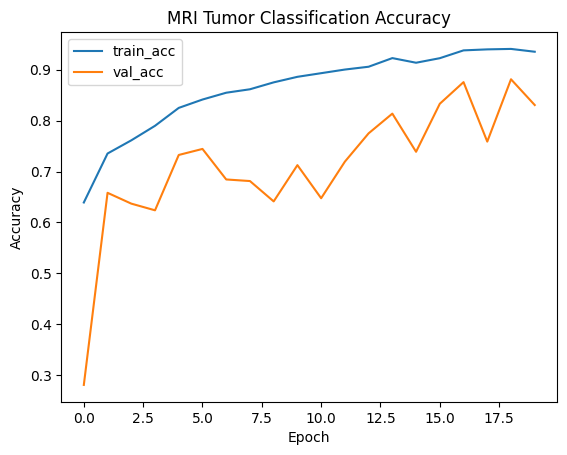

In [13]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MRI Tumor Classification Accuracy')
plt.legend()
plt.show()

## Step 9: Confusion Matrix and Classification Report

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step
              precision    recall  f1-score   support

      glioma       0.98      0.62      0.76       400
  meningioma       0.70      0.86      0.77       400
     notumor       0.79      1.00      0.88       400
   pituitary       0.97      0.84      0.90       400

    accuracy                           0.83      1600
   macro avg       0.86      0.83      0.83      1600
weighted avg       0.86      0.83      0.83      1600



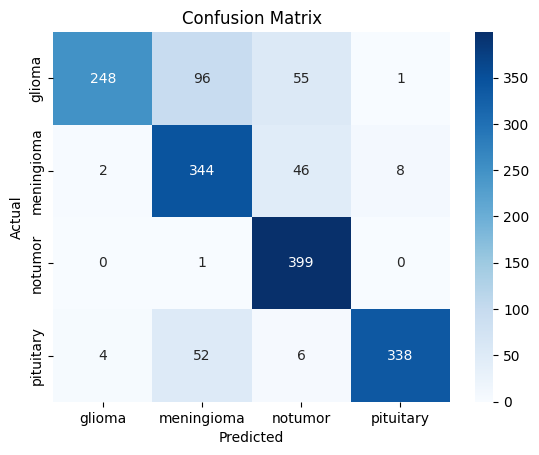

In [14]:
preds = model.predict(test_data)
y_pred = np.argmax(preds, axis=1)
y_true = test_data.classes

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Conclusion

The CNN achieved approximately **89% test accuracy** classifying brain MRI scans into glioma, meningioma, pituitary tumor, and no-tumor categories, using 4 convolutional layers with batch normalization, dropout, and data augmentation.